In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
import seaborn.objects as so
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyhelpers import make_outattr_metadata
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmvatxw
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2025-12-10-complexty-fitness-correlation
notebook path: /home/runner/work/oee4/oee4/binder/2025-12-10-complexty-fitness-correlation.ipynb
revision: bdac574
timestamp: 2026-01-17T20:16:43Z00:00

IPython==7.16.1
packaging==25.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-12-10-complexty-fitness-correlation"


# get data


In [5]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

series_profiles, = bucket_handle.objects.filter(
    Prefix=f'endeavor=16/series-profiles/stage=8+what=elaborated/',
)


In [6]:
df = pd.read_csv(
    f's3://prq49/{series_profiles.key}',
    compression='xz',
)
dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
dfdigest


<ipython-input-6-747b1fe91af5>:1: DtypeWarning: Columns (2270,2277,2284,2285,2286,2287,2289,2290,2291,2292,2298,2299,2300,2301,2302,2308,2309,2310) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


'-1af9f0eb89153a8e'

In [7]:
def make_outattr_metadata():
    return {}


In [8]:
for stint in df['Stint'].unique():
    exec(f'df{stint} = df[ df["Stint"] == {stint} ]')


In [9]:
dfm10 = df[ df['Stint'] % 10 == 0 ]


In [10]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfnone = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfnone["kind"] = "none"
print(dfnone["Competition Stint"].unique())
print(dfnone["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [11]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfbio = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfbio["kind"] = "eco"
print(dfbio["Competition Stint"].unique())
print(dfbio["Competition Series"].unique())


[ 10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24  25
  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40  41
  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57  58
  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73  74
  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9  90
  91  92  93  94  95  96  97  98  99]
[16000 16001 16002 16003 16004 16005 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [12]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfabio = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions-focalbb/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfabio["kind"] = "self"
print(dfabio["Competition Stint"].unique())
print(dfabio["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [13]:
dfabio.columns


Index(['Competition Stint', 'Competition Series', 'Competition Replicate',
       'Competition Treatment', 'Treatment _', 'Treatment mut_sever',
       'Treatment mut_freq', 'Treatment diversity', 'Treatment bucket',
       'Competition Endeavor', 'Competition Repro', 'Competition Slurm Job ID',
       'Competition Thread', 'Competition Process', 'Update',
       'Population Slots', 'Num Live Cells', 'Population Extinct',
       'Num Live Cells with Focal Root ID', 'Focal Root ID Cells Extinct',
       'Is Focal Root ID', 'Abundance', 'Prevalence', 'Focal Prevalence',
       'Root ID', 'Genome Slug', 'Genome Filename', 'Fitness Differential',
       'Fitness Differential Focal', 'Count', 'Extrospective State Target Idx',
       'Inter Message Self-Send Filter Mod',
       'Inter Message Self-Send Filter Target',
       'Intermittent Extrospective State Exchange Probability',
       'Intermittent Extrospective State Rotate Probability',
       'Intermittent Introspective State Exchange 

In [14]:
dfx = pd.concat([dfabio, dfbio, dfnone], ignore_index=True)
dfx["Fitness Differential Focal Sign"] = np.sign(
    dfx["Fitness Differential Focal"],
)
dfx["Series"] = dfx["Competition Series"]
dfx["Stint"] = dfx["Competition Stint"]
dfx["flip series"] = dfx["genome series"] * (dfx["Root ID"] == 1)
dfx["Competitor"] = (
    dfx
    .groupby(["Stint", "Series", "kind", "Competition Repro"])
    ["flip series"]
    .transform("max")
)
dfx = dfx[
    dfx["Root ID"] == 0
].groupby(["Stint", "Series", "kind", "Competitor"])[
    "Focal Prevalence"
].mean().round().reset_index(drop=False)
dfx


,Stint,Series,kind,Competitor,Focal Prevalence
0,1,16005,none,16000,1.0
1,1,16005,none,16001,0.0
2,1,16005,none,16002,0.0
3,1,16005,none,16003,0.0
4,1,16005,none,16004,0.0
...,...,...,...,...,...
59117,100,16039,self,16035,0.0
59118,100,16039,self,16036,1.0
59119,100,16039,self,16037,0.0
59120,100,16039,self,16038,0.0


In [15]:
dfj = dfx.join(
    dfm10[
        [
            "Stint",
            "Series",
            "Fitness Complexity",
            "Flagged Advantageous Sites",
            "Flagged Deleterious Sites",
        ]
    ].set_index(
        ["Stint", "Series"]
    ),
    on=["Stint", "Series"],
    how="inner",
).reset_index(drop=False)
dfj["Favored"] = dfj["Focal Prevalence"] > 0.5
dfj


,index,Stint,Series,kind,Competitor,Focal Prevalence,Fitness Complexity,Flagged Advantageous Sites,Flagged Deleterious Sites,Favored
0,1040,10,16000,eco,16000,1.0,11.52,12.0,3.0,True
1,1041,10,16000,eco,16001,1.0,11.52,12.0,3.0,True
2,1042,10,16000,eco,16002,0.0,11.52,12.0,3.0,False
3,1043,10,16000,eco,16003,0.0,11.52,12.0,3.0,False
4,1044,10,16000,eco,16004,0.0,11.52,12.0,3.0,False
...,...,...,...,...,...,...,...,...,...,...
47875,59117,100,16039,self,16035,0.0,14.67,17.0,0.0,False
47876,59118,100,16039,self,16036,1.0,14.67,17.0,0.0,True
47877,59119,100,16039,self,16037,0.0,14.67,17.0,0.0,False
47878,59120,100,16039,self,16038,0.0,14.67,17.0,0.0,False


In [16]:
palette = [
    sns.color_palette("Dark2")[2],
    sns.color_palette("Dark2")[4],
    sns.color_palette("Dark2")[0],
]


teeplots/2025-12-10-complexty-fitness-correlation/col=stint+hue=kind+viz=lmplot+x=flagged-advantageous-sites+y=focal-prevalence+ext=.pdf
teeplots/2025-12-10-complexty-fitness-correlation/col=stint+hue=kind+viz=lmplot+x=flagged-advantageous-sites+y=focal-prevalence+ext=.png


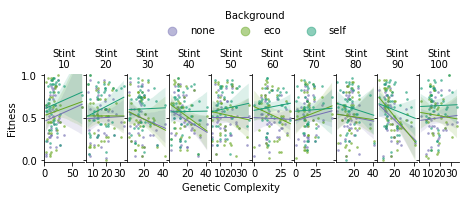

In [17]:
for (y,) in it.product(
    ["Focal Prevalence"],
):
    dfjx = dfj.groupby(
        ["Series", "kind", "Stint"],
    ).mean().reset_index(drop=False)
    with tp.teed(
        sns.lmplot,
        data=dfjx,
        col="Stint",
        x="Flagged Advantageous Sites",
        y=y,
        hue="kind",
        hue_order=["none", "eco", "self"],
        line_kws={"lw": 1.0},
        facet_kws=dict(
            sharex=False,
            sharey=True,
        ),
        palette=palette,
        scatter_kws={"alpha": 0.5, "clip_on": False, "s": 3},
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(6, 1.5)
        g.set_xlabels("Genetic Complexity")
        g.set_ylabels("Fitness")
        g.set_titles("Stint\n{col_name}")
        g.set(ylim=(-0.02, 1.02))
        for i, ax in enumerate(g.axes.flat):
            if i != 4:
                ax.set_xlabel(None)
        sns.move_legend(
            g,
            "lower center",
            bbox_to_anchor=(0.5, 1.2),
            ncol=3,
            frameon=False,
            markerscale=5,
            title="Background",
        )


teeplots/2025-12-10-complexty-fitness-correlation/hue=kind+viz=lmplot+x=flagged-advantageous-sites+y=focal-prevalence+ext=.pdf
teeplots/2025-12-10-complexty-fitness-correlation/hue=kind+viz=lmplot+x=flagged-advantageous-sites+y=focal-prevalence+ext=.png


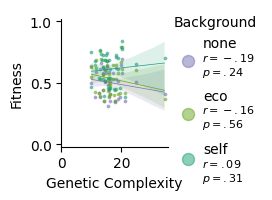

,kind,correlation,pvalue
0,self,0.096046,0.555490
1,eco,-0.190002,0.240272
2,none,-0.163898,0.312225


In [18]:
for (y,) in it.product(
    ["Focal Prevalence"],
):
    dfjx = dfj.groupby(["Series", "kind", "Stint"]).mean().reset_index(
        drop=False,
    )
    dfjx = dfjx.groupby(["Series", "kind"]).mean().reset_index(drop=False)
    with tp.teed(
        sns.lmplot,
        data=dfjx.replace(
            {"none": "none\n\n", "eco": "eco\n\n", "self": "self\n"},
        ),
        x="Flagged Advantageous Sites",
        y=y,
        hue="kind",
        hue_order=["none\n\n", "eco\n\n", "self\n"],
        facet_kws=dict(
            sharex=False,
            sharey=True,
        ),
        line_kws={"lw": 0.5},
        palette=palette,
        scatter_kws={"alpha": 0.5, "clip_on": False, "s": 3},
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(1.5, 1.5)
        g.set_ylabels("Fitness")
        g.set_titles("Stint {col_name}")
        g.set(xlim=(0, None), ylim=(-0.02, 1.02))
        for i, ax in enumerate(g.axes.flat):
            if i != 4:
                ax.set_xlabel(None)
        sns.move_legend(
            g,
            "upper left",
            bbox_to_anchor=(0.8, 1.08),
            handletextpad=0.1,
            ncol=1,
            frameon=False,
            markerscale=5,
            title="Background",
        )
        legend = g._legend
        legend._legend_box.align = "left"

        ax.annotate(
            f"$r = -.19$\n$p = .24$",
            xy=(1.32, 0.56),
            xycoords="axes fraction",
            fontsize=8,
        )
        ax.annotate(
            f"$r = -.16$\n$p = .56$",
            xy=(1.32, 0.12),
            xycoords="axes fraction",
            fontsize=8,
            va="bottom",
        )
        ax.annotate(
            f"$r = .09$\n$p = .31$",
            xy=(1.32, -0.30),
            xycoords="axes fraction",
            fontsize=8,
            va="bottom",
        )
        ax.set_xlabel("Genetic Complexity")

    res = []
    from scipy import stats as scipy_stats
    for kind in ["self", "eco", "none"]:
        stat = scipy_stats.pearsonr(
            dfjx[
                dfjx["kind"] == kind
            ]["Flagged Advantageous Sites"],
            dfjx[
                dfjx["kind"] == kind
            ][y],
        )
        res.append({
            "kind": kind,
            "correlation": stat[0],
            "pvalue": stat[1],
        })

    display(pd.DataFrame(res))


teeplots/2025-12-10-complexty-fitness-correlation/agg=False+hue=kind+kind=violin+viz=catplot+x=complex+y=focal-prevalence+ext=.pdf
teeplots/2025-12-10-complexty-fitness-correlation/agg=False+hue=kind+kind=violin+viz=catplot+x=complex+y=focal-prevalence+ext=.png


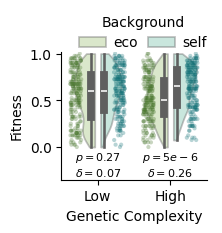

,Complex,U,p-value,delta,magnitude
0,High,25391.0,0.000005,small,0.263234
1,Low,21286.5,0.195258,negligible,0.075049


,U,p-value,delta,magnitude
0,93155.5,0.000042,small,0.167362


,Kind,U,p-value,delta,magnitude
0,self,21803.5,0.118564,negligible,0.090202
1,eco,18043.5,0.106943,negligible,-0.093291


In [19]:
light_palette=[
    "#a3cf73",
    "#6dceb1",
]
dark_palette=[
    "#4a772f",
    "#137177",
]

for (y,) in it.product(
    ["Focal Prevalence"],
):
    dfjx = dfj.groupby(["Series", "kind", "Stint"]).mean().reset_index(
        drop=False,
    )
    thresh = dfjx["Flagged Advantageous Sites"].median()
    dfjx["Complex"] = dfjx["Flagged Advantageous Sites"] >= thresh
    dfjx["Complex"] = dfjx["Complex"].map({True: "High", False: "Low"})
    with tp.teed(
        sns.catplot,
        data=dfjx[
            dfjx["kind"].isin(["self", "eco"])
        ],
        x="Complex",
        y=y,
        hue="kind",
        hue_order=["eco", "self"],
        order=["Low", "High"],
        alpha=0.4,
        cut=0,
        dodge=True,
        gap=0.2,
        kind="violin",
        palette=light_palette,
        split=True,
        teeplot_outattrs={"agg": False},
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(2, 1.5)
        g.set_xlabels("Genetic Complexity")
        g.set_ylabels("Fitness")
        g.set_titles("Stint {col_name}")
        g.set(ylim=(-0.02, 1.02))
        for i, ax in enumerate(g.axes.flat):
            if i != 4:
                ax.set_xlabel(None)
        np.random.seed(1)
        sns.stripplot(
            data=dfjx[
                dfjx["kind"].isin(["self", "eco"])
            ],
            x="Complex",
            y=y,
            hue="kind",
            hue_order=["eco", None, None, "self"],
            alpha=0.3,
            ax=ax,

            dodge=True,
            order=["Low", "High"],
            jitter=0.3,
            legend=False,
            palette=dark_palette + dark_palette,
            size=3,
        )
        sns.move_legend(
            g,
            "lower center",
            bbox_to_anchor=(.54, 0.9),
            columnspacing=0.7,
            frameon=False,
            handletextpad=0.5,
            ncol=2,
            title="Background",
        )
        ax.annotate(
            f"$p = 0.27$\n$\delta = 0.07$",
            xy=(0.25, 0.01),
            xycoords="axes fraction",
            fontsize=8,
            ha="center",
            va="bottom",
        )
        ax.annotate(
            f"$p = 5e-6$\n$\delta = 0.26$",
            xy=(0.75, 0.01),
            xycoords="axes fraction",
            fontsize=8,
            ha="center",
            va="bottom",
        )
        g.set_xlabels("Genetic Complexity")
        g.set(ylim=(-0.35, None))

res = []
for complex in ["High", "Low"]:
    stat = scipy_stats.mannwhitneyu(
        dfjx[
            (dfjx["kind"] == "self") &
            (dfjx["Complex"] == complex)
        ]["Focal Prevalence"],
        dfjx[
            (dfjx["kind"] == "eco") &
            (dfjx["Complex"] == complex)
        ]["Focal Prevalence"],
        alternative="two-sided",
    )
    magnitude, delta = cliffs_delta(
        dfjx[
            (dfjx["kind"] == "self") &
            (dfjx["Complex"] == complex)
        ]["Focal Prevalence"],
        dfjx[
            (dfjx["kind"] == "eco") &
            (dfjx["Complex"] == complex)
        ]["Focal Prevalence"],
    )
    res.append(
        {
            "Complex": complex,
            "U": stat.statistic,
            "p-value": stat.pvalue,
            "delta": delta,
            "magnitude": magnitude,
        }
    )
display(pd.DataFrame(res))

res = []
stat = scipy_stats.mannwhitneyu(
    dfjx[
        (dfjx["kind"] == "self")
    ]["Focal Prevalence"],
    dfjx[
        (dfjx["kind"] == "eco")
    ]["Focal Prevalence"],
    alternative="two-sided",
)
magnitude, delta = cliffs_delta(
    dfjx[
        (dfjx["kind"] == "self")
    ]["Focal Prevalence"],
    dfjx[
        (dfjx["kind"] == "eco")
    ]["Focal Prevalence"],
)
res.append(
    {
        "U": stat.statistic,
        "p-value": stat.pvalue,
        "delta": delta,
        "magnitude": magnitude,
    }
)
display(pd.DataFrame(res))

res = []
for kind in ["self", "eco"]:
    stat = scipy_stats.mannwhitneyu(
        dfjx[
            (dfjx["kind"] == kind) &
            (dfjx["Complex"] == "High")
        ]["Focal Prevalence"],
        dfjx[
            (dfjx["kind"] == kind) &
            (dfjx["Complex"] == "Low")
        ]["Focal Prevalence"],
        alternative="two-sided",
    )
    magnitude, delta = cliffs_delta(
        dfjx[
            (dfjx["kind"] == kind) &
            (dfjx["Complex"] == "High")
        ]["Focal Prevalence"],
        dfjx[
            (dfjx["kind"] == kind) &
            (dfjx["Complex"] == "Low")
        ]["Focal Prevalence"],
    )
    res.append(
        {
            "Kind": kind,
            "U": stat.statistic,
            "p-value": stat.pvalue,
            "delta": delta,
            "magnitude": magnitude,
        }
    )
display(pd.DataFrame(res))


kind     eco  none  self
Complex                 
High      20    20    20
Low       20    20    20
teeplots/2025-12-10-complexty-fitness-correlation/agg=True+hue=kind+kind=violin+viz=catplot+x=complex+y=focal-prevalence+ext=.pdf
teeplots/2025-12-10-complexty-fitness-correlation/agg=True+hue=kind+kind=violin+viz=catplot+x=complex+y=focal-prevalence+ext=.png


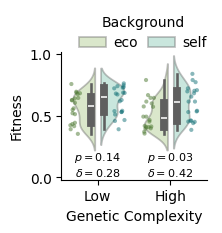

,Complex,U,p-value,delta,magnitude
0,High,283.0,0.025577,medium,0.4150
1,Low,255.5,0.136742,small,0.2775


,Complex,U,p-value,delta,magnitude
0,Low,1084.5,0.006274,medium,0.355625


,Kind,U,p-value,delta,magnitude
0,self,180.0,0.597742,negligible,-0.100
1,eco,145.0,0.140364,small,-0.275


In [20]:
for (y,) in it.product(
    ["Focal Prevalence"],
):
    dfjx = dfj.groupby(["Series", "kind", "Stint"]).mean().reset_index(
        drop=False,
    )
    dfjx = dfjx.groupby(["Series", "kind"]).mean().reset_index(drop=False)
    thresh = dfjx["Flagged Advantageous Sites"].median()
    dfjx["Complex"] = dfjx["Flagged Advantageous Sites"] >= thresh
    dfjx["Complex"] = dfjx["Complex"].map({True: "High", False: "Low"})
    print(pd.crosstab(dfjx["Complex"], dfjx["kind"]))
    with tp.teed(
        sns.catplot,
        data=dfjx[
            dfjx["kind"].isin(["self", "eco"])
        ],
        x="Complex",
        y=y,
        hue="kind",
        hue_order=["eco", "self"],
        order=["Low", "High"],
        alpha=0.4,
        dodge=True,
        gap=0.2,
        kind="violin",
        palette=light_palette,
        split=True,
        teeplot_outattrs={"agg": True},
        teeplot_subdir=teeplot_subdir,
    ) as g:
        g.figure.set_size_inches(2, 1.5)
        g.set_xlabels("Genetic Complexity")
        g.set_ylabels("Fitness")
        g.set_titles("Stint {col_name}")
        g.set(ylim=(-0.02, 1.02))
        for i, ax in enumerate(g.axes.flat):
            if i != 4:
                ax.set_xlabel(None)
        np.random.seed(1)
        sns.stripplot(
            data=dfjx[
                dfjx["kind"].isin(["self", "eco"])
            ],
            x="Complex",
            y=y,
            hue="kind",
            hue_order=["eco", None, None, "self"],
            alpha=0.5,
            ax=ax,

            dodge=True,
            order=["Low", "High"],
            jitter=0.3,
            legend=False,
            palette=dark_palette + dark_palette,
            size=3,
        )
        sns.move_legend(
            g,
            "lower center",
            bbox_to_anchor=(.54, 0.9),
            columnspacing=0.7,
            frameon=False,
            handletextpad=0.5,
            ncol=2,
            title="Background",
        )
        ax.annotate(
            f"$p = 0.14$\n$\delta = 0.28$",
            xy=(0.25, 0.01),
            xycoords="axes fraction",
            fontsize=8,
            ha="center",
            va="bottom",
        )
        ax.annotate(
            f"$p = 0.03$\n$\delta = 0.42$",
            xy=(0.75, 0.01),
            xycoords="axes fraction",
            fontsize=8,
            ha="center",
            va="bottom",
        )
        g.set_xlabels("Genetic Complexity")

res = []
for complex in ["High", "Low"]:
    stat = scipy_stats.mannwhitneyu(
        dfjx[
            (dfjx["kind"] == "self") &
            (dfjx["Complex"] == complex)
        ]["Focal Prevalence"],
        dfjx[
            (dfjx["kind"] == "eco") &
            (dfjx["Complex"] == complex)
        ]["Focal Prevalence"],
        alternative="two-sided",
    )
    magnitude, delta = cliffs_delta(
        dfjx[
            (dfjx["kind"] == "self") &
            (dfjx["Complex"] == complex)
        ]["Focal Prevalence"],
        dfjx[
            (dfjx["kind"] == "eco") &
            (dfjx["Complex"] == complex)
        ]["Focal Prevalence"],
    )
    res.append(
        {
            "Complex": complex,
            "U": stat.statistic,
            "p-value": stat.pvalue,
            "delta": delta,
            "magnitude": magnitude,
        }
    )
display(pd.DataFrame(res))

res = []
stat = scipy_stats.mannwhitneyu(
    dfjx[
        (dfjx["kind"] == "self")
    ]["Focal Prevalence"],
    dfjx[
        (dfjx["kind"] == "eco")
    ]["Focal Prevalence"],
    alternative="two-sided",
)
magnitude, delta = cliffs_delta(
    dfjx[
        (dfjx["kind"] == "self")
    ]["Focal Prevalence"],
    dfjx[
        (dfjx["kind"] == "eco")
    ]["Focal Prevalence"],
)
res.append(
    {
        "Complex": complex,
        "U": stat.statistic,
        "p-value": stat.pvalue,
        "delta": delta,
        "magnitude": magnitude,
    }
)
display(pd.DataFrame(res))

res = []
for kind in ["self", "eco"]:
    stat = scipy_stats.mannwhitneyu(
        dfjx[
            (dfjx["kind"] == kind) &
            (dfjx["Complex"] == "High")
        ]["Focal Prevalence"],
        dfjx[
            (dfjx["kind"] == kind) &
            (dfjx["Complex"] == "Low")
        ]["Focal Prevalence"],
        alternative="two-sided",
    )
    magnitude, delta = cliffs_delta(
        dfjx[
            (dfjx["kind"] == kind) &
            (dfjx["Complex"] == "High")
        ]["Focal Prevalence"],
        dfjx[
            (dfjx["kind"] == kind) &
            (dfjx["Complex"] == "Low")
        ]["Focal Prevalence"],
    )
    res.append(
        {
            "Kind": kind,
            "U": stat.statistic,
            "p-value": stat.pvalue,
            "delta": delta,
            "magnitude": magnitude,
        }
    )
display(pd.DataFrame(res))
